<a href="https://colab.research.google.com/github/ealeongomez/RFF-HBO-TSF/blob/main/test/Custom_Layer_RFF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Preliminares**

In [1]:
!pip install torchinfo optuna botorch gpytorch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.9/779.9 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.7/277.7 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.3/176.3 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.4/55.4 kB 5.5 MB/s eta 0:00:00


In [2]:
!git clone https://github.com/ealeongomez/RFF-HBO-TSF.git

Cloning into 'RFF-HBO-TSF'...
remote: Enumerating objects: 49, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 49 (delta 14), reused 39 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (49/49), 24.04 MiB | 5.83 MiB/s, done.
Resolving deltas: 100% (14/14), done.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math, pickle
from tqdm import tqdm
from scipy.interpolate import griddata

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
#from torchinfo import summary
from torchsummary import summary
from torch.utils.data import TensorDataset, DataLoader

import optuna
import optuna.visualization as vis
#from optuna_integration.botorch import BoTorchSampler
from optuna.samplers import TPESampler
from optuna.samplers import GPSampler
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_slice, plot_parallel_coordinate

from scipy.stats import norm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.gaussian_process import GaussianProcessRegressor

import warnings
warnings.filterwarnings("ignore")

In [26]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# **Load dataset**

In [4]:
pkl_filename = "/content/RFF-HBO-TSF/Data/data_dict.pkl"

with open(pkl_filename, "rb") as f:
    data_dict_loaded = pickle.load(f)

In [5]:
def make_loader(X_arr, y_arr, batch_size, shuffle=False):
    ds = TensorDataset(torch.tensor(X_arr, dtype=torch.float32), torch.tensor(y_arr, dtype=torch.float32))
    return DataLoader(ds, batch_size=batch_size, shuffle=False)

In [6]:
data_dict_loaded.keys()

dict_keys(['Etiopia-April', 'Etiopia-May', 'Argone', 'Beijing', 'Chengdu', 'Netherland-0', 'Netherland-1', 'Netherland-2', 'Lorenz systems 0.5', 'Lorenz systems 3', 'Lorenz systems 5'])

In [7]:
names_TSF = ['Lorenz systems 0.5']

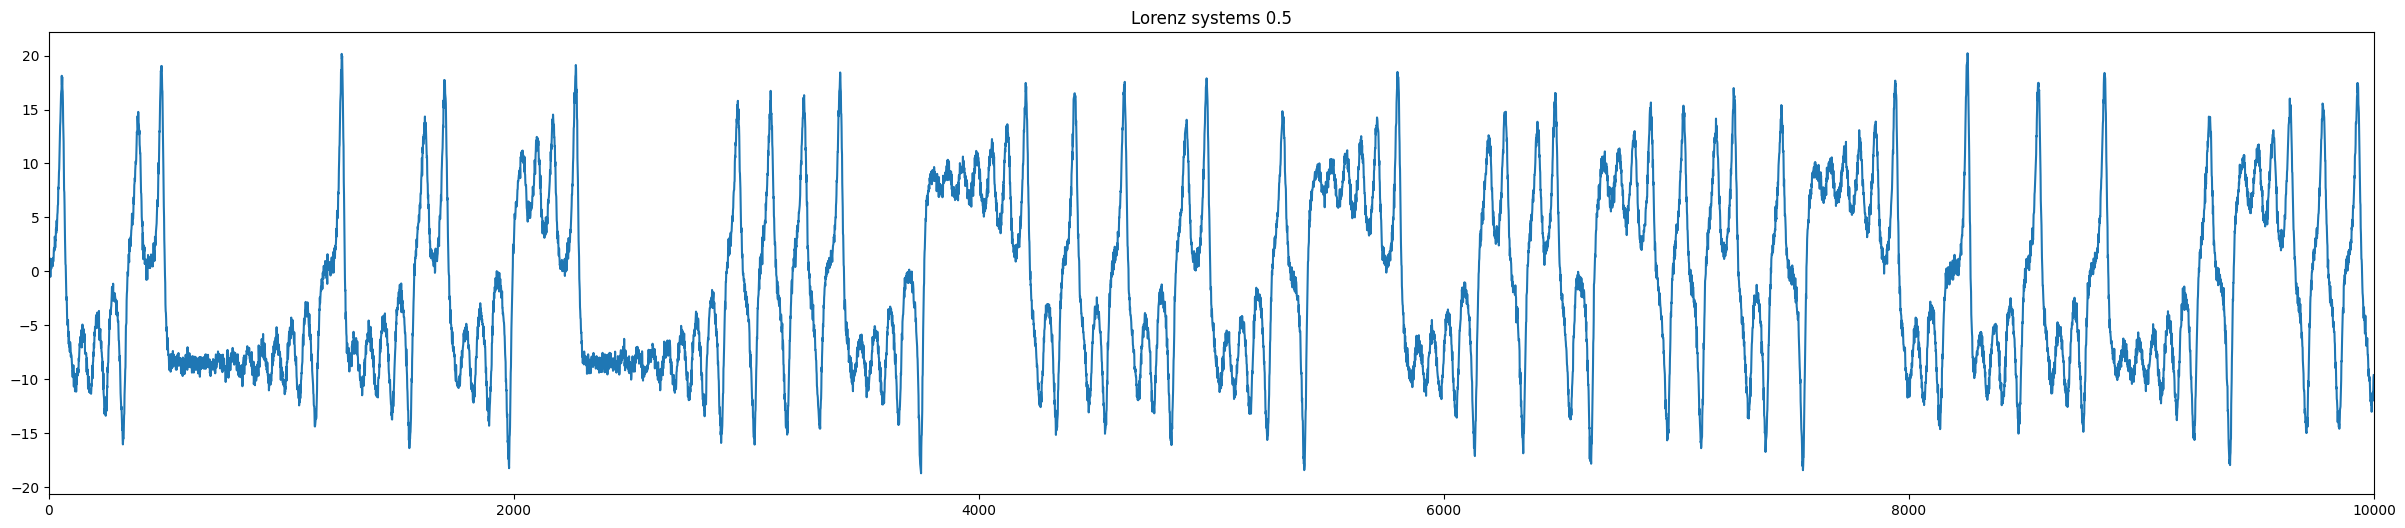

In [8]:
plt.figure(figsize=(30, 6))
plt.plot(data_dict_loaded[names_TSF[0]]['time_series'])
plt.title(names_TSF[0])
plt.xlim(0, len(data_dict_loaded[names_TSF[0]]['time_series']))
plt.show()

In [9]:
data = {}

for folder_name in names_TSF:
    print(f"\nFolder: {folder_name}")

    # Inicializar sección
    data[folder_name] = {}

    X = data_dict_loaded[f"{folder_name}"]['X']
    Y = data_dict_loaded[f"{folder_name}"]['Y']

    print(X.shape, Y.shape)

    X = X[..., np.newaxis]  # Expand dims for CNN

    print(X.shape, Y.shape)

    # Train/Validation/Test splits
    X_temp, X_test, y_temp, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
    X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

    if folder_name == "Etiopia-April" or folder_name == "Etiopia-May":
        batch_size = 64
    else:
        batch_size = 256

    train_loader = make_loader(X_train, y_train, batch_size)
    valid_loader = make_loader(X_valid, y_valid, batch_size)
    test_loader  = make_loader(X_test,  y_test, batch_size)

    data[folder_name] = {"loaders": {"train": train_loader, "valid": valid_loader, "test":  test_loader}}


Folder: Lorenz systems 0.5
(9962, 30) (9962, 7)
(9962, 30, 1) (9962, 7)


# **Models**

## **Loss function**

In [10]:
class KernelMSELoss_PT(nn.Module):
    def __init__(self, sigma=None):
        super(KernelMSELoss_PT, self).__init__()
        if sigma is None:
            sigma = math.sqrt(2) / 2
        self.sigma2 = 2 * sigma ** 2

    def forward(self, y_pred, y_true):
        diff_squared = (y_true - y_pred) ** 2
        loss = 1 - torch.exp(-diff_squared / self.sigma2)
        return torch.mean(loss)

## RFF custom layer

In [11]:
import torch
import torch.nn as nn
import numpy as np

class DenseRFF_PT(nn.Module):
    def __init__(self, Nf, scale=None, gamma=None, normalization=True,
                 function="cos", trainable_scale=True, trainable_W=True,
                 seed=None, kernel='gaussian'):
        """
        Implementación de Random Fourier Features (RFF).
        """
        super(DenseRFF_PT, self).__init__()
        self.Nf = Nf
        self.gamma = gamma
        self.scale = scale
        self.normalization = normalization
        self.function = function
        self.trainable_scale = trainable_scale
        self.trainable_W = trainable_W
        self.seed = seed
        self.kernel_type = kernel

        self.W = None
        self.b = None
        self.kernel_scale = None

    def _get_random_features_initializer(self, shape, sigma=1.0, seed=None):
        if seed is not None:
            np.random.seed(seed)
        if self.kernel_type == 'gaussian':
            return np.random.randn(*shape) / sigma
        elif self.kernel_type == 'laplacian':
            return np.random.laplace(loc=0.0, scale=1.0, size=shape) / sigma
        else:
            raise ValueError(f'Unsupported initializer {self.kernel_type}')

    def forward(self, inputs):
        device = inputs.device

        # Espera [B,T,D] o [B,D]; no hace permutaciones automáticas
        if inputs.dim() == 2:
            inputs = inputs.unsqueeze(1)   # [B,D] -> [B,1,D]
        elif inputs.dim() != 3:
            raise ValueError(f"Se esperaba [B,T,D] o [B,D], recibido: {inputs.shape}")

        B, T, D = inputs.shape

        if self.W is None:
            if self.gamma is not None:
                sigma = np.sqrt(1.0 / (2 * self.gamma))
            else:
                sigma = 1.0
            if self.scale is None:
                self.scale = sigma

            W_init = self._get_random_features_initializer((D, self.Nf), sigma=self.scale, seed=self.seed)
            self.W = nn.Parameter(torch.tensor(W_init, dtype=torch.float32, device=device),
                                  requires_grad=self.trainable_W)

            b_init = np.random.uniform(0.0, 2 * np.pi, size=(self.Nf,))
            self.b = nn.Parameter(torch.tensor(b_init, dtype=torch.float32, device=device),
                                  requires_grad=self.trainable_W)

            self.kernel_scale = nn.Parameter(torch.tensor([1.0], dtype=torch.float32, device=device),
                                             requires_grad=self.trainable_scale)

        proj = torch.matmul(inputs, self.W * self.kernel_scale) + self.b  # [B,T,Nf]

        if self.function == "cos":
            outputs = torch.cos(proj)
            norm = np.sqrt(self.Nf)
        elif self.function == "sin":
            outputs = torch.sin(proj)
            norm = np.sqrt(self.Nf)
        elif self.function == "cos_sin":
            outputs = torch.cat([torch.cos(proj), torch.sin(proj)], dim=-1)
            norm = np.sqrt(2*self.Nf)   # ajuste correcto
        else:
            raise ValueError(f"Función desconocida {self.function}")

        outputs = outputs * np.sqrt(2.0)
        if self.normalization:
            outputs = outputs / norm

        return outputs.permute(0, 2, 1)  # [B,Nf( o 2Nf si cos_sin), T]




In [12]:
rff_layer = DenseRFF_PT(Nf=100, gamma=0.5, function="cos", normalization=True, seed=123)
x = torch.randn(100, 30, 1)   # (batch, window, channels)
y = rff_layer(x)

print("Input:", x.shape)
print("Output:", y.shape)

Input: torch.Size([100, 30, 1])
Output: torch.Size([100, 100, 30])


## RNN + RFF

In [13]:
class DenseRFF_ForecastNet(nn.Module):
    def __init__(self,
                 window: int = 30,
                 prediction_horizon: int = 7,
                 rff_output_dim: int = 64,
                 rnn_type: str = None,
                 rnn_hidden_size: int = 32,
                 rnn_num_layers: int = 1,
                 rnn_bidirectional: bool = False):
        super().__init__()

        self.prediction_horizon = prediction_horizon
        self.rff_output_dim = rff_output_dim
        self.use_rnn = rnn_type is not None

        # 1) RNN opcional
        if self.use_rnn:
            rnn_cls = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[rnn_type]
            self.rnn = rnn_cls(
                input_size=1,
                hidden_size=rnn_hidden_size,
                num_layers=rnn_num_layers,
                bidirectional=rnn_bidirectional,
                batch_first=True
            )
            self.rnn_out_dim = rnn_hidden_size * (2 if rnn_bidirectional else 1)
        else:
            self.rnn_out_dim = 1

        # 2) Capa RFF densa
        self.rff = DenseRFF_PT(
            Nf=rff_output_dim,
            gamma=None,
            scale=None,
            function="cos",
            normalization=True,
            trainable_scale=True,
            trainable_W=True,
            seed=42,
            kernel="gaussian"
        )

        # 3) Capa fully-connected
        # ⚠️ No inicializamos fc1 aquí, la creamos en el primer forward
        self.fc1 = None
        self.fc2 = nn.Linear(128, prediction_horizon)  # salida fija

        self.relu = nn.ReLU()

    def forward(self, x):
        # Entrada [B, T, 1]
        if self.use_rnn:
            x, _ = self.rnn(x)   # [B, T, H]
        # Si no hay RNN, ya es [B,T,1]

        # Aplicar RFF
        x = self.rff(x)  # [B, Nf, T]

        # Flatten
        x = x.reshape(x.size(0), -1)  # [B, Nf*T]

        # Inicializar fc1 dinámicamente si no existe
        if self.fc1 is None:
            self.fc1 = nn.Linear(x.size(1), 128).to(x.device)

        x = self.fc1(x)
        x = self.relu(x)
        return self.fc2(x)



## Train


In [14]:
def train_model(model, data, folder_name, num_epochs=50, lr=1e-3, device="cuda", trial=None):
    loaders = data[folder_name]["loaders"]
    train_loader = loaders["train"]
    valid_loader = loaders["valid"]
    test_loader  = loaders["test"]

    # Detectar hiperparámetros del dataset
    xb0, yb0 = next(iter(train_loader))
    window  = xb0.shape[1]
    horizon = yb0.shape[1]

    # Ajuste dinámico de la capa de salida (por si cambia el dataset)
    if hasattr(model, "fc2") and model.fc2.out_features != horizon:
        model.fc2 = nn.Linear(model.fc2.in_features, horizon).to(device)

    model = model.to(device)
    criterion = KernelMSELoss_PT()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val = float("inf")
    history = {"train_loss": [], "valid_loss": []}

    for epoch in range(1, num_epochs + 1):
        # -------- Train
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * xb.size(0)
        train_loss /= len(train_loader.dataset)

        # -------- Valid
        model.eval()
        valid_loss = 0.0
        with torch.no_grad():
            for xb, yb in valid_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                loss = criterion(preds, yb)
                valid_loss += loss.item() * xb.size(0)
        valid_loss /= len(valid_loader.dataset)

        history["train_loss"].append(train_loss)
        history["valid_loss"].append(valid_loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch:03d} | Train {train_loss:.4f} | Valid {valid_loss:.4f}")

        # Guardar mejor
        if valid_loss < best_val:
            best_val = valid_loss
            torch.save(model.state_dict(), f"best_model_{folder_name}.pth")

        # NEW: Reportar a Optuna y activar pruning
        if trial is not None:
            # Reportamos -valid_loss para que "más alto es mejor" (consistente con maximize)
            trial.report(-valid_loss, step=epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

    # -------- Test con mejor modelo
    model.load_state_dict(torch.load(f"best_model_{folder_name}.pth", map_location=device))
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            y_true.append(yb.cpu())
            y_pred.append(preds.cpu())

    y_true = torch.cat(y_true).numpy()
    y_pred = torch.cat(y_pred).numpy()

    # Métricas globales
    r2   = float(r2_score(y_true, y_pred))
    mae  = float(mean_absolute_error(y_true, y_pred))
    mse  = float(mean_squared_error(y_true, y_pred))
    rmse = float(np.sqrt(mse))
    print(f"Test GLOBAL | R2={r2:.4f} | MAE={mae:.4f} | RMSE={rmse:.4f}")

    # Métricas puntuales
    H = y_true.shape[1]
    metrics_pointwise = {"horizon": [], "RMSE": [], "MAE": [], "R2": []}
    for h in range(H):
        yt = y_true[:, h]
        yp = y_pred[:, h]
        mse_h = mean_squared_error(yt, yp)
        rmse_h = np.sqrt(mse_h)
        mae_h  = mean_absolute_error(yt, yp)
        r2_h   = r2_score(yt, yp)
        metrics_pointwise["horizon"].append(h+1)
        metrics_pointwise["RMSE"].append(float(rmse_h))
        metrics_pointwise["MAE"].append(float(mae_h))
        metrics_pointwise["R2"].append(float(r2_h))
    df_pointwise = pd.DataFrame(metrics_pointwise)

    #print("\t\n", df_pointwise)

    # Métricas acumuladas
    metrics_cumulative = {"horizon": [], "RMSE": [], "MAE": [], "R2": []}
    for h in range(1, H+1):
        yt = y_true[:, :h].reshape(-1)
        yp = y_pred[:, :h].reshape(-1)
        mse_h = mean_squared_error(yt, yp)
        rmse_h = np.sqrt(mse_h)
        mae_h  = mean_absolute_error(yt, yp)
        r2_h   = r2_score(yt, yp)
        metrics_cumulative["horizon"].append(h)
        metrics_cumulative["RMSE"].append(float(rmse_h))
        metrics_cumulative["MAE"].append(float(mae_h))
        metrics_cumulative["R2"].append(float(r2_h))
    df_cumulative = pd.DataFrame(metrics_cumulative)

    #print("\t\n", df_cumulative)

    return history, df_pointwise, df_cumulative





In [15]:
def plot_reconstruction_per_horizon(y_true, y_pred, num_samples=500, folder_name="dataset"):
    N, H = y_true.shape
    num_samples = min(num_samples, N)

    for h in range(H):
        plt.figure(figsize=(14, 4))
        plt.plot(range(num_samples), y_true[:num_samples, h],
                 label=f"Real (h={h+1})", color="blue", linewidth=1.5)
        plt.plot(range(num_samples), y_pred[:num_samples, h],
                 label=f"Predicho (h={h+1})", color="red", linestyle="--")
        plt.title(f"Reconstrucción Test - {folder_name} (Horizonte {h+1})")
        plt.xlabel("Índice de muestra")
        plt.ylabel("Valor")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()



# **Bayes optimization**

In [16]:
from functools import partial
import os, shutil, optuna
from optuna.samplers import TPESampler

def objetive_cmae(
    trial,
    net_type: str,                     # None | "RNN" | "GRU" | "LSTM"
    *,
    dataset_key: str,                  # clave EXACTA en data[...] (p.ej. "Beijing", "Lorenz systems 0.5")
    window: int,
    horizon: int,
    data: dict,
    lr: float = 1e-3,
    num_epochs: int = 60,
    device: str = "cuda",
    rff_dim_choices=(16, 32, 64, 96, 128, 192, 256),
    rnn_hidden_size: int = 64,
    rnn_num_layers: int = 1,
    rnn_bidirectional: bool = False,
    run_dir_base: str = "runs/rffdim_search",
):
    # Validación para evitar KeyError
    if dataset_key not in data or "loaders" not in data[dataset_key]:
        raise KeyError(f"dataset_key='{dataset_key}' no válido. Claves: {list(data.keys())}")

    # ÚNICO hiperparámetro a optimizar
    rff_output_dim = trial.suggest_categorical("rff_output_dim", list(rff_dim_choices))

    # Modelo
    model = DenseRFF_ForecastNet(
        window=window,
        prediction_horizon=horizon,
        rff_output_dim=rff_output_dim,
        rnn_type=net_type,
        rnn_hidden_size=rnn_hidden_size,
        rnn_num_layers=rnn_num_layers,
        rnn_bidirectional=rnn_bidirectional,
    )

    # ENTRENAR (nota: folder_name debe ser la clave del dataset)
    history, df_pointwise, df_cumulative = train_model(
        model=model,
        data=data,
        folder_name=dataset_key,
        num_epochs=num_epochs,
        lr=lr,
        device=device,
        trial=trial,
    )

    # MAE acumulativo en TEST: última fila (agrega todos los horizontes)
    cmae_test = float(df_cumulative["MAE"].iloc[-1])

    # Guarda para análisis posterior
    trial.set_user_attr("cmae_test", cmae_test)
    trial.set_user_attr("rff_output_dim", int(rff_output_dim))
    trial.set_user_attr("cmae_curve", df_cumulative["MAE"].tolist())

    # (opcional) Copiar el mejor modelo a carpeta del trial
    src = f"best_model_{dataset_key}.pth"
    dst_dir = os.path.join(run_dir_base, dataset_key, f"trial{trial.number}_rff{rff_output_dim}")
    os.makedirs(dst_dir, exist_ok=True)
    if os.path.exists(src):
        shutil.copy(src, os.path.join(dst_dir, os.path.basename(src)))

    # OBJETIVO: MINIMIZAR el MAE acumulativo
    return cmae_test



In [37]:
dataset_key = names_TSF[0]

# Inferir window/horizon una sola vez desde los loaders del dataset elegido
xb0, yb0 = next(iter(data[dataset_key]["loaders"]["train"]))
window  = int(xb0.shape[1])
horizon = int(yb0.shape[1])

# Redes a evaluar: Dense (None), RNN, GRU, LSTM
nets = [
    ("Dense", None),
    ("RNN",   "RNN"),
    ("GRU",   "GRU"),
    ("LSTM",  "LSTM"),
]

# Para guardar estudios y resultados
studies   = {}
rows_all  = []

from functools import partial
import optuna
from optuna.samplers import TPESampler
from optuna.trial import TrialState

for label, net_type in nets:
    print(f"\n===================== Optimizando {label} en dataset={dataset_key} =====================")

    # Sampler/Pruner por estudio (igual que tu patrón original)
    sampler = TPESampler(seed=42)
    pruner  = optuna.pruners.NopPruner()

    study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)

    # Mismo esquema que tu ejemplo, solo cambiando net_type y run_dir_base
    objective_net = partial(
        objetive_cmae,
        net_type=net_type,
        dataset_key=dataset_key,
        window=window,
        horizon=horizon,
        data=data,
        lr=1e-3,
        num_epochs=100,
        device=device,
        rff_dim_choices=tuple(range(4, 101, 1)),
        rnn_hidden_size=32,
        rnn_num_layers=1,
        rnn_bidirectional=False,
        run_dir_base=f"runs/{label.lower()}_rffdim_search",
    )

    study.optimize(objective_net, n_trials=25, gc_after_trial=True)

    print("Best CMAE:", study.best_value)
    print("Best params:", study.best_trial.params)

    studies[label] = study

    # Guardar todos los trials para graficar error vs parámetro
    for t in study.trials:
        if t.state != TrialState.COMPLETE:
            continue
        rows_all.append({
            "net_type": label,
            "trial": t.number,
            "rff_output_dim": int(t.params["rff_output_dim"]),
            "cmae_test": float(t.user_attrs.get("cmae_test", t.value)),  # guardado en objetive_cmae
        })


[I 2025-10-01 14:31:16,428] A new study created in memory with name: no-name-735699a3-3c04-4163-8ecf-59da1cafc1f2



===================== Optimizando Dense en dataset=Lorenz systems 0.5 =====================
Epoch 010 | Train 0.9351 | Valid 0.9344
Epoch 020 | Train 0.9286 | Valid 0.9298


[I 2025-10-01 14:31:19,888] Trial 0 finished with value: 6.763646602630615 and parameters: {'rff_output_dim': 8}. Best is trial 0 with value: 6.763646602630615.


Epoch 030 | Train 0.9234 | Valid 0.9257
Test GLOBAL | R2=0.0755 | MAE=6.7636 | RMSE=7.8915
Epoch 010 | Train 0.9375 | Valid 0.9357
Epoch 020 | Train 0.9317 | Valid 0.9309


[I 2025-10-01 14:31:23,914] Trial 1 finished with value: 7.053051948547363 and parameters: {'rff_output_dim': 16}. Best is trial 0 with value: 6.763646602630615.


...

Epoch 030 | Train 0.3702 | Valid 0.3695
Test GLOBAL | R2=0.9626 | MAE=0.9513 | RMSE=1.5872
Epoch 010 | Train 0.8559 | Valid 0.8535
Epoch 020 | Train 0.5655 | Valid 0.5620


[I 2025-10-01 14:37:49,670] Trial 23 finished with value: 1.139281153678894 and parameters: {'rff_output_dim': 4}. Best is trial 22 with value: 0.9512972235679626.


Epoch 030 | Train 0.3756 | Valid 0.3722
Test GLOBAL | R2=0.9331 | MAE=1.1393 | RMSE=2.1224
Epoch 010 | Train 0.8708 | Valid 0.8709
Epoch 020 | Train 0.5323 | Valid 0.5298


[I 2025-10-01 14:37:54,301] Trial 24 finished with value: 1.0606446266174316 and parameters: {'rff_output_dim': 4}. Best is trial 22 with value: 0.9512972235679626.


Epoch 030 | Train 0.3843 | Valid 0.3815
Test GLOBAL | R2=0.9507 | MAE=1.0606 | RMSE=1.8230
Best CMAE: 0.9512972235679626
Best params: {'rff_output_dim': 4}


In [40]:
# Resúmenes útiles
df_trials = pd.DataFrame(rows_all).sort_values(["net_type","rff_output_dim","cmae_test"]).reset_index(drop=True)
df_best = pd.DataFrame(
    [{"net_type": lbl,
      "best_rff_output_dim": int(st.best_trial.params["rff_output_dim"]),
      "best_cmae": float(st.best_value)} for lbl, st in studies.items()]
).sort_values("best_cmae").reset_index(drop=True)

display(df_best)


,net_type,best_rff_output_dim,best_cmae
0,LSTM,4,0.951297
1,GRU,4,1.209266
2,RNN,4,1.325834
3,Dense,8,6.498338


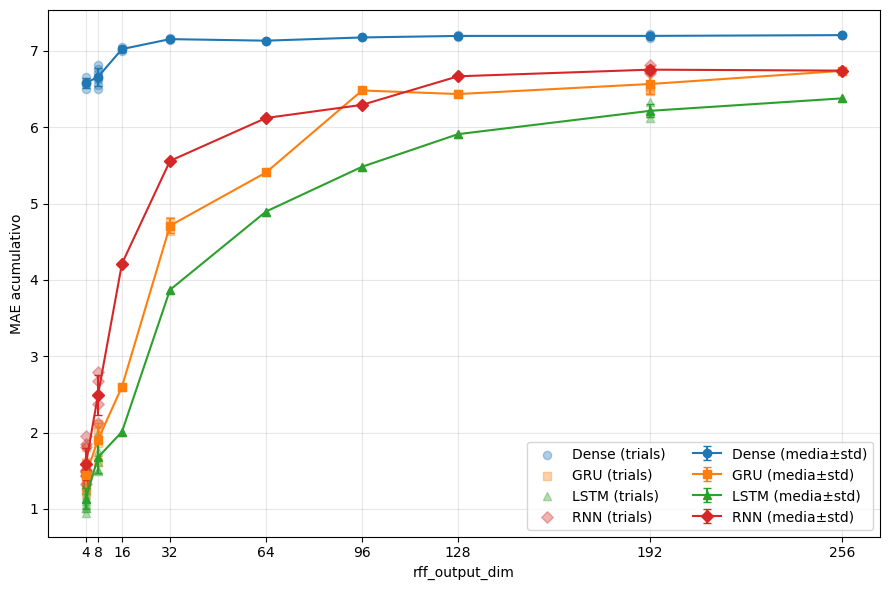

In [41]:
dfp = df_trials.copy()
dfp["rff_output_dim"] = dfp["rff_output_dim"].astype(int)
dfp = dfp.sort_values(["net_type","rff_output_dim","cmae_test"]).reset_index(drop=True)

# Agregado por red y parámetro
agg = (
    dfp.groupby(["net_type","rff_output_dim"])["cmae_test"]
       .agg(["mean","std","count"])
       .reset_index()
)

plt.figure(figsize=(9,6))

markers = ["o", "s", "^", "D", "P", "X"]
marker_map = {}

for i, net in enumerate(sorted(dfp["net_type"].unique())):
    # scatter: todos los trials de esa red
    sub = dfp[dfp["net_type"] == net]
    marker_map[net] = markers[i % len(markers)]
    plt.scatter(
        sub["rff_output_dim"], sub["cmae_test"],
        alpha=0.35, s=35, label=f"{net} (trials)", marker=marker_map[net]
    )

    # línea + barras de error: media ± std
    suba = agg[agg["net_type"] == net].sort_values("rff_output_dim")
    plt.errorbar(
        suba["rff_output_dim"], suba["mean"], yerr=suba["std"],
        fmt=f"-{marker_map[net]}", capsize=3, linewidth=1.5, label=f"{net} (media±std)"
    )

# Mejor punto global (anotación)
best_idx = dfp["cmae_test"].idxmin()
best_x   = int(dfp.loc[best_idx, "rff_output_dim"])
best_y   = float(dfp.loc[best_idx, "cmae_test"])
best_net = dfp.loc[best_idx, "net_type"]

#plt.annotate(f"Mejor: {best_net}, dim={best_x}, CMAE={best_y:.4f}", xy=(best_x, best_y), xytext=(10, 12), textcoords="offset points", arrowprops=dict(arrowstyle="->", lw=1))

plt.xlabel("rff_output_dim")
plt.ylabel("MAE acumulativo")
plt.grid(True, alpha=0.3)
plt.xticks(sorted(dfp["rff_output_dim"].unique()))
plt.legend(ncols=2, frameon=True)
plt.tight_layout()
plt.show()


# **Forecasting**

In [63]:
results = {}

window = data_dict_loaded[folder_name]['X'].shape[1]          # longitud de la ventana
horizon = data_dict_loaded[folder_name]['Y'].shape[1]         # horizonte de predicción

for _, row in df_best.iterrows():
    print(f"\n🏋️‍♀️💻 ====================================== Training: RFF-{row['net_type']} \n\t")

    net_type = row['net_type']
    if net_type == "Dense":
        net_type = None

    model = DenseRFF_ForecastNet(
        window=window,
        prediction_horizon=horizon,
        rff_output_dim=row['best_rff_output_dim'],
        rnn_type=net_type,
        rnn_hidden_size=32,
        rnn_num_layers=1
    )

    history, df_pointwise, df_cumulative = train_model(
        model,
        data,
        folder_name=names_TSF[0],
        num_epochs=500,
        lr=1e-3,
        device="cuda" if torch.cuda.is_available() else "cpu"
    )

    print(df_cumulative)

    # Añadir columna con el tipo de red
    df_cumulative["net_type"] = row['net_type']

    # Guardar en lista de resultados
    results[f"RFF-{row['net_type']}"] = df_cumulative.copy()



🏋️‍♀️💻 ====================================== Training: RFF-LSTM 
	
Epoch 010 | Train 0.8578 | Valid 0.8552
Epoch 020 | Train 0.5570 | Valid 0.5499
Epoch 030 | Train 0.4091 | Valid 0.4063
Epoch 040 | Train 0.3591 | Valid 0.3583
Epoch 050 | Train 0.3354 | Valid 0.3371
Epoch 060 | Train 0.3181 | Valid 0.3205
Epoch 070 | Train 0.3039 | Valid 0.3077
Epoch 080 | Train 0.2921 | Valid 0.2955
Epoch 090 | Train 0.2838 | Valid 0.2867
Epoch 100 | Train 0.2774 | Valid 0.2797
Epoch 110 | Train 0.2721 | Valid 0.2736
Epoch 120 | Train 0.2677 | Valid 0.2692
Epoch 130 | Train 0.2639 | Valid 0.2646
Epoch 140 | Train 0.2609 | Valid 0.2605
Epoch 150 | Train 0.2572 | Valid 0.2568
Epoch 160 | Train 0.2540 | Valid 0.2545
Epoch 170 | Train 0.2504 | Valid 0.2508
Epoch 180 | Train 0.2478 | Valid 0.2485
Epoch 190 | Train 0.2457 | Valid 0.2468
Epoch 200 | Train 0.2437 | Valid 0.2451
Epoch 210 | Train 0.2419 | Valid 0.2441
Epoch 220 | Train 0.2404 | Valid 0.2433
Epoch 230 | Train 0.2389 | Valid 0.2414
Epoch 240 |

In [64]:
results

{'RFF-LSTM':    horizon      RMSE       MAE        R2 net_type
 0        1  0.596057  0.471096  0.994676     LSTM
 1        2  0.585949  0.465050  0.994862     LSTM
 2        3  0.582687  0.462258  0.994935     LSTM
 3        4  0.584386  0.464353  0.994915     LSTM
 4        5  0.586410  0.466025  0.994884     LSTM
 5        6  0.590683  0.468932  0.994814     LSTM
 6        7  0.597575  0.473647  0.994698     LSTM,
 'RFF-GRU':    horizon      RMSE       MAE        R2 net_type
 0        1  0.632844  0.493208  0.993998      GRU
 1        2  0.628896  0.487549  0.994082      GRU
 2        3  0.626417  0.487870  0.994147      GRU
 3        4  0.630391  0.489131  0.994083      GRU
 4        5  0.635240  0.492353  0.993997      GRU
 5        6  0.640300  0.495911  0.993906      GRU
 6        7  0.648168  0.499564  0.993762      GRU,
 'RFF-RNN':    horizon      RMSE       MAE        R2 net_type
 0        1  0.645893  0.508328  0.993748      RNN
 1        2  0.635842  0.501359  0.993950     

In [65]:
df_summary = pd.concat(results, ignore_index=True)
print(df_summary)

    horizon      RMSE       MAE        R2 net_type
0         1  0.596057  0.471096  0.994676     LSTM
1         2  0.585949  0.465050  0.994862     LSTM
2         3  0.582687  0.462258  0.994935     LSTM
3         4  0.584386  0.464353  0.994915     LSTM
4         5  0.586410  0.466025  0.994884     LSTM
5         6  0.590683  0.468932  0.994814     LSTM
6         7  0.597575  0.473647  0.994698     LSTM
7         1  0.632844  0.493208  0.993998      GRU
8         2  0.628896  0.487549  0.994082      GRU
9         3  0.626417  0.487870  0.994147      GRU
10        4  0.630391  0.489131  0.994083      GRU
11        5  0.635240  0.492353  0.993997      GRU
12        6  0.640300  0.495911  0.993906      GRU
13        7  0.648168  0.499564  0.993762      GRU
14        1  0.645893  0.508328  0.993748      RNN
15        2  0.635842  0.501359  0.993950      RNN
16        3  0.633385  0.497462  0.994016      RNN
17        4  0.636064  0.498538  0.993976      RNN
18        5  0.641381  0.502107

In [66]:
import torch
import torch.nn as nn

class RecurrentForecastNet(nn.Module):
    """
    Mismo esqueleto que DenseRFF_ForecastNet pero SIN capa RFF:
      (opcional) RNN -> [B,T,F]  --transponer--> [B,F,T] --flatten--> FC(·,128) -> ReLU -> FC(128,H)

    Entrada:  x de forma [B, T, 1]
    Salida:   y_hat de forma [B, prediction_horizon]
    """
    def __init__(self,
                 window: int = 30,
                 prediction_horizon: int = 7,
                 # (Se conserva la firma para comparar uno-a-uno)
                 rff_output_dim: int = 64,          # <- ignorado en esta clase; se deja por compatibilidad
                 rnn_type: str = None,              # None | 'RNN' | 'GRU' | 'LSTM'
                 rnn_hidden_size: int = 32,
                 rnn_num_layers: int = 1,
                 rnn_bidirectional: bool = False):
        super().__init__()

        self.prediction_horizon = prediction_horizon
        self.use_rnn = rnn_type is not None

        if self.use_rnn:
            if rnn_type not in {"RNN", "GRU", "LSTM"}:
                raise ValueError("rnn_type debe ser 'RNN', 'GRU', 'LSTM' o None.")
            rnn_cls = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[rnn_type]
            self.rnn = rnn_cls(
                input_size=1,
                hidden_size=rnn_hidden_size,
                num_layers=rnn_num_layers,
                bidirectional=rnn_bidirectional,
                batch_first=True
            )
            feat = rnn_hidden_size * (2 if rnn_bidirectional else 1)  # F
        else:
            self.rnn = None
            feat = 1  # si no hay RNN, mantenemos el canal original

        # Igual que en tu clase original: fc1 se define en el primer forward
        self.fc1 = None
        self.fc2 = nn.Linear(128, prediction_horizon)
        self.relu = nn.ReLU()

        # guardamos F para documentar, no es obligatorio
        self._feat = feat

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [B, T, 1]
        """
        # 1) Paso recurrente opcional: out [B, T, F]
        if self.use_rnn:
            x, _ = self.rnn(x)  # [B, T, F]
        # si no hay RNN, x ya es [B, T, 1] → F=1

        # 2) Transponer para emular la forma [B, F, T] que antes salía de RFF
        x = x.transpose(1, 2)  # [B, F, T]

        # 3) Aplanar tiempo y features como en tu DenseRFF (Nf*T → ahora F*T)
        x = x.reshape(x.size(0), -1)  # [B, F*T]

        # 4) Inicializar fc1 de forma diferida (como en tu clase original)
        if self.fc1 is None:
            self.fc1 = nn.Linear(x.size(1), 128).to(x.device)

        x = self.fc1(x)
        x = self.relu(x)
        return self.fc2(x)



In [67]:
# Filtrar solo redes recurrentes válidas
valid_nets = {"RNN", "GRU", "LSTM"}
df_run = df_best[df_best["net_type"].isin(valid_nets)].copy()

for _, row in df_run.iterrows():
    print(f"\n🏋️‍♀️💻 ====================================== Training: {row['net_type']} \n\t")

    net_type = row['net_type']  # 'RNN' | 'GRU' | 'LSTM'

    # ---- Modelo SOLO recurrente (sin RFF) ----
    model = RecurrentForecastNet(
          window=window,
          prediction_horizon=horizon,
          rnn_type=net_type,        # None | 'RNN' | 'GRU' | 'LSTM'
          rnn_hidden_size=32,
          rnn_num_layers=1,
          rnn_bidirectional=False
      )

    # ---- Entrenar ----
    history, df_pointwise, df_cumulative = train_model(
        model=model,
        data=data,
        folder_name=folder_name,   # clave del dataset en 'data'
        num_epochs=500,
        lr=1e-3,
        device=device
    )

    print(df_cumulative)

    df_cumulative["net_type"] = net_type

    results[f"{row['net_type']}"] = df_cumulative.copy()




🏋️‍♀️💻 ====================================== Training: LSTM 
	
Epoch 010 | Train 0.9053 | Valid 0.9002
Epoch 020 | Train 0.4818 | Valid 0.4804
Epoch 030 | Train 0.3297 | Valid 0.3330
Epoch 040 | Train 0.2908 | Valid 0.2967
Epoch 050 | Train 0.2706 | Valid 0.2754
Epoch 060 | Train 0.2592 | Valid 0.2634
Epoch 070 | Train 0.2522 | Valid 0.2567
Epoch 080 | Train 0.2461 | Valid 0.2518
Epoch 090 | Train 0.2402 | Valid 0.2473
Epoch 100 | Train 0.2356 | Valid 0.2442
Epoch 110 | Train 0.2297 | Valid 0.2386
Epoch 120 | Train 0.2258 | Valid 0.2356
Epoch 130 | Train 0.2229 | Valid 0.2324
Epoch 140 | Train 0.2212 | Valid 0.2281
Epoch 150 | Train 0.2193 | Valid 0.2258
Epoch 160 | Train 0.2181 | Valid 0.2244
Epoch 170 | Train 0.2194 | Valid 0.2233
Epoch 180 | Train 0.2173 | Valid 0.2238
Epoch 190 | Train 0.2151 | Valid 0.2232
Epoch 200 | Train 0.2138 | Valid 0.2215
Epoch 210 | Train 0.2127 | Valid 0.2210
Epoch 220 | Train 0.2120 | Valid 0.2210
Epoch 230 | Train 0.2113 | Valid 0.2211
Epoch 240 | Tra

In [68]:
results

{'RFF-LSTM':    horizon      RMSE       MAE        R2 net_type
 0        1  0.596057  0.471096  0.994676     LSTM
 1        2  0.585949  0.465050  0.994862     LSTM
 2        3  0.582687  0.462258  0.994935     LSTM
 3        4  0.584386  0.464353  0.994915     LSTM
 4        5  0.586410  0.466025  0.994884     LSTM
 5        6  0.590683  0.468932  0.994814     LSTM
 6        7  0.597575  0.473647  0.994698     LSTM,
 'RFF-GRU':    horizon      RMSE       MAE        R2 net_type
 0        1  0.632844  0.493208  0.993998      GRU
 1        2  0.628896  0.487549  0.994082      GRU
 2        3  0.626417  0.487870  0.994147      GRU
 3        4  0.630391  0.489131  0.994083      GRU
 4        5  0.635240  0.492353  0.993997      GRU
 5        6  0.640300  0.495911  0.993906      GRU
 6        7  0.648168  0.499564  0.993762      GRU,
 'RFF-RNN':    horizon      RMSE       MAE        R2 net_type
 0        1  0.645893  0.508328  0.993748      RNN
 1        2  0.635842  0.501359  0.993950     

In [69]:
import pandas as pd
from tabulate import tabulate

# Unificar todos los DataFrames del diccionario en uno solo
df_all = pd.concat(results, axis=0)
df_all.reset_index(inplace=True)
df_all.rename(columns={"level_0": "Model", "level_1": "Index"}, inplace=True)
df_all.drop(columns=["Index"], inplace=True)

# Mostrar tabla completa (primeras filas) con tabulate
print("\n📊 Resultados organizados:")
print(tabulate(df_all.head(20), headers="keys", tablefmt="grid", showindex=False))

# También puedes pivotear para comparar métricas por horizonte
df_pivot_rmse = df_all.pivot(index="horizon", columns="Model", values="RMSE")
df_pivot_mae  = df_all.pivot(index="horizon", columns="Model", values="MAE")
df_pivot_r2   = df_all.pivot(index="horizon", columns="Model", values="R2")

print("\n🔎 RMSE comparativo por horizonte:")
print(tabulate(df_pivot_rmse, headers="keys", tablefmt="grid", floatfmt=".4f"))

print("\n🔎 MAE comparativo por horizonte:")
print(tabulate(df_pivot_mae, headers="keys", tablefmt="grid", floatfmt=".4f"))

print("\n🔎 R2 comparativo por horizonte:")
print(tabulate(df_pivot_r2, headers="keys", tablefmt="grid", floatfmt=".4f"))




📊 Resultados organizados:
+----------+-----------+----------+----------+----------+------------+
| Model    |   horizon |     RMSE |      MAE |       R2 | net_type   |
+==========+===========+==========+==========+==========+============+
| RFF-LSTM |         1 | 0.596057 | 0.471096 | 0.994676 | LSTM       |
+----------+-----------+----------+----------+----------+------------+
| RFF-LSTM |         2 | 0.585949 | 0.46505  | 0.994862 | LSTM       |
+----------+-----------+----------+----------+----------+------------+
| RFF-LSTM |         3 | 0.582687 | 0.462258 | 0.994935 | LSTM       |
+----------+-----------+----------+----------+----------+------------+
| RFF-LSTM |         4 | 0.584386 | 0.464353 | 0.994915 | LSTM       |
+----------+-----------+----------+----------+----------+------------+
| RFF-LSTM |         5 | 0.58641  | 0.466025 | 0.994884 | LSTM       |
+----------+-----------+----------+----------+----------+------------+
| RFF-LSTM |         6 | 0.590683 | 0.468932 | 0.9